In [73]:
import open3d as o3d
import numpy as np
from PIL import Image
from scipy.spatial.transform import Rotation as R
import glob
import os
import time
import re
import numpy as np
import zarr
import sys

sys.path.append(os.path.abspath("..")) 

In [74]:
root = zarr.open('../../../zed2i_vio_map', mode='r')

odo_timestamps = root['timestamp'][:]
odo_pos = root['pose_pos'][:]        # Shape: (4949, 3) -> [x, y, z] in World Frame
odo_orien = root['pose_orien'][:]

In [75]:
def find_nearest_odo_index(odo_timestamps, target_timestamp):
    """Finds index of the closest odometry timestamp to an image timestamp."""
    return np.argmin(np.abs(odo_timestamps - target_timestamp))

def project_future_trajectory(current_idx, odo_pos, odo_orien, lookahead_steps=30):
    """
    Transforms future world odometry positions into current vehicle/ego frame.
    
    Returns:
        forward_x: Forward distance in meters (Ego X)
        lateral_y:  Lateral distance in meters (Ego Y)
    """
    # Ego reference pose at image capture time
    p_0 = odo_pos[current_idx]
    q_0 = odo_orien[current_idx]
    
    # World-to-Ego Rotation Matrix (Transpose of Ego-to-World)
    # Assumes quaternion format [x, y, z, w] (ZED default)
    r_0 = R.from_quat(q_0).as_matrix()
    r_world_to_ego = r_0.T  
    
    # Slice future odometry points in World Frame
    end_idx = min(current_idx + lookahead_steps, len(odo_pos))
    future_pos_world = odo_pos[current_idx:end_idx]
    
    # Transform to relative Ego coordinates: P_ego = R_w2e * (P_world - P_0)
    pos_diff = future_pos_world - p_0
    pos_ego = np.dot(pos_diff, r_world_to_ego.T)
    
    forward_x = pos_ego[:, 0]  # Ego X (Forward)
    lateral_y = pos_ego[:, 1]  # Ego Y (Lateral)
    
    return forward_x, lateral_y

In [76]:
from utils.BEV_helper_functions import build_pcd, generate_bev_from_o3d,ranges
def frame_id(path):
    m = re.search(r'(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else 0

DEPTH = "../../../zed2i_depth_image/"
RGB = "../../../zed2i_right_images/"  

rgb_files = sorted(glob.glob(os.path.join(RGB, "*.jpeg")), key=frame_id)
depth_files = sorted(glob.glob(os.path.join(DEPTH, "*.png")), key=frame_id)

X_RANGE, Y_RANGE = ranges()

IMG_INDEX = 300

In [77]:

img_root = zarr.open('../../../zed2i_right_images_data', mode='r')
image_timestamps = img_root['timestamp'][:]
image_timestamp = img_root['timestamp'][IMG_INDEX]

# 1. Match timestamp to nearest odometry pose index
curr_odo_idx = find_nearest_odo_index(odo_timestamps, image_timestamp)

# 2. Get relative forward (X) and lateral (Y) points for the next 30 frames
forward_x, lateral_y = project_future_trajectory(
    current_idx=curr_odo_idx, 
    odo_pos=odo_pos, 
    odo_orien=odo_orien, 
    lookahead_steps=60
)

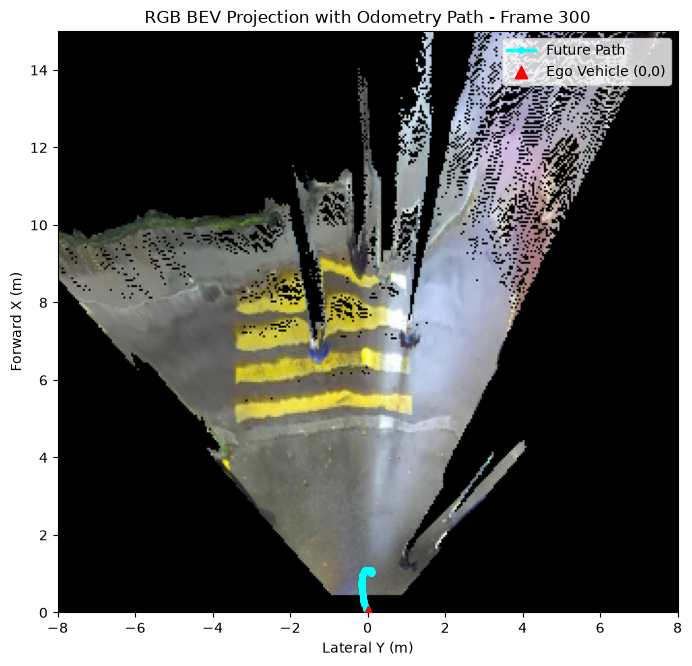

In [78]:
import matplotlib.pyplot as plt

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Initialize axes
ax.set_xlabel("Lateral Y (m)")
ax.set_ylabel("Forward X (m)")
ax.set_title("RGB BEV Projection with Odometry Path - Frame " + str(IMG_INDEX))

# 2. Generate BEV
first_pcd = build_pcd(rgb_files[IMG_INDEX], depth_files[IMG_INDEX])
bev_map = generate_bev_from_o3d(first_pcd, x_range=X_RANGE, y_range=Y_RANGE)

rgb = np.transpose(bev_map[6:9], (1, 2, 0))
if np.nanmax(rgb) > 1.0:
    rgb = rgb / 255.0
rgb_vis = np.nan_to_num(rgb)

# 3. Render BEV Image
im = ax.imshow(rgb_vis, extent=[Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]])

# 4. Plot Trajectory Overlay
# In Matplotlib: x-axis is Lateral Y, y-axis is Forward X
ax.plot(lateral_y, forward_x, color='cyan', linewidth=2.5, marker='o', markersize=4, label='Future Path')
ax.scatter([0], [0], color='red', s=80, marker='^', zorder=5, label='Ego Vehicle (0,0)')

ax.set_xlim(Y_RANGE[0], Y_RANGE[1])
ax.set_ylim(X_RANGE[0], X_RANGE[1])
ax.legend(loc='upper right')

plt.show()

### Creating the training patch

In [83]:
import numpy as np
import matplotlib.patches as patches

# Dimensions of the cell in meters
CELL_LENGTH_X = 1.0  # Forward X (930 mm)
CELL_WIDTH_Y  = 1.0  # Lateral Y (530 mm)

# Target center position of the cell in Ego frame (meters)
# Adjust x_center and y_center to place the box anywhere on the BEV map
x_center = 2.0  # 1.0 meter forward
y_center = 0.0  # Centered laterally

# Compute bounding box limits in meters
x_min_cell = x_center - (CELL_LENGTH_X / 2.0)
x_max_cell = x_center + (CELL_LENGTH_X / 2.0)
y_min_cell = y_center - (CELL_WIDTH_Y / 2.0)
y_max_cell = y_center + (CELL_WIDTH_Y / 2.0)

In [84]:
# Image shape: H (Forward X rows), W (Lateral Y columns)
H, W = rgb_vis.shape[0], rgb_vis.shape[1]

# Spatial resolution (meters per pixel)
res_x = (X_RANGE[1] - X_RANGE[0]) / H
res_y = (Y_RANGE[1] - Y_RANGE[0]) / W

# Convert spatial bounds (meters) to pixel indices
# Origin 'lower' means row 0 corresponds to X_RANGE[0]
row_min = int(np.clip((x_min_cell - X_RANGE[0]) / res_x, 0, H))
row_max = int(np.clip((x_max_cell - X_RANGE[0]) / res_x, 0, H))
col_min = int(np.clip((y_min_cell - Y_RANGE[0]) / res_y, 0, W))
col_max = int(np.clip((y_max_cell - Y_RANGE[0]) / res_y, 0, W))

# Extract sub-array (cropped cell)
cropped_cell = rgb_vis[row_min:row_max, col_min:col_max]

print(f"Extracted Cell Array Shape: {cropped_cell.shape}")

Extracted Cell Array Shape: (20, 20, 3)


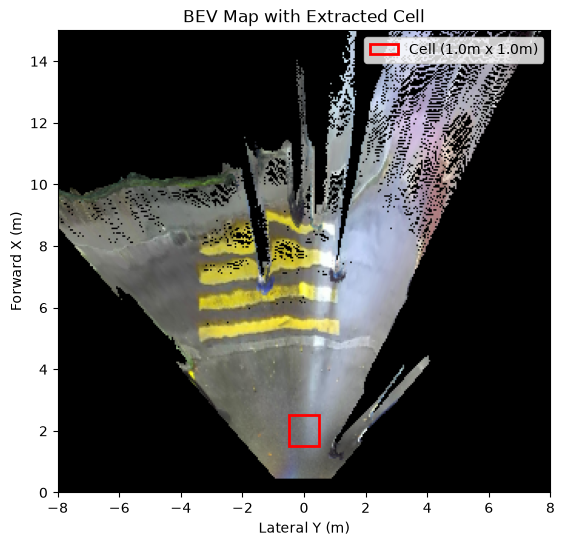

In [85]:
# Plot full BEV with the cell bounding box overlaid
fig, ax_bev = plt.subplots(figsize=(8, 6))

# Full BEV Projection
ax_bev.imshow(rgb_vis, extent=[Y_RANGE[0], Y_RANGE[1], X_RANGE[0], X_RANGE[1]])
ax_bev.set_xlabel("Lateral Y (m)")
ax_bev.set_ylabel("Forward X (m)")
ax_bev.set_title("BEV Map with Extracted Cell")

# Add bounding box patch: Rectangle((bottom_left_y, bottom_left_x), width_y, length_x)
cell_box = patches.Rectangle(
    (y_min_cell, x_min_cell),
    CELL_WIDTH_Y,
    CELL_LENGTH_X,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    label=f'Cell ({CELL_LENGTH_X}m x {CELL_WIDTH_Y}m)'
)
ax_bev.add_patch(cell_box)
ax_bev.legend(loc='upper right')

Text(0.5, 1.0, 'Extracted Cell (1.0m x 1.0m)')

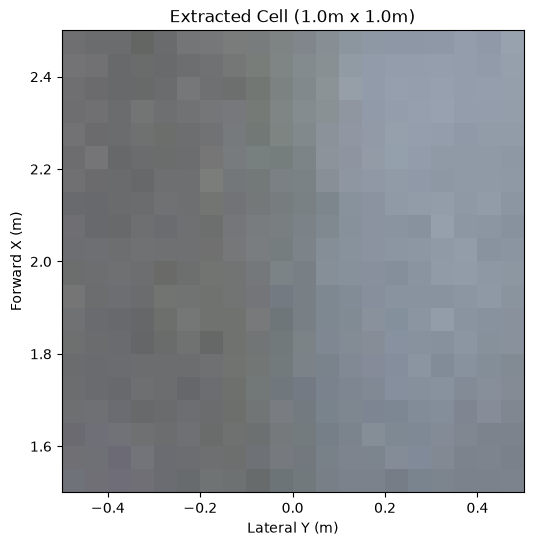

In [86]:
# Convert spatial metric coordinates to pixel indices
height_px, width_px = rgb_vis.shape[:2]

y_scale = width_px / (Y_RANGE[1] - Y_RANGE[0])
x_scale = height_px / (X_RANGE[1] - X_RANGE[0])

# Calculate pixel bounds (assuming origin is top-left for arrays)
col_start = int((y_min_cell - Y_RANGE[0]) * y_scale)
col_end = int((y_max_cell - Y_RANGE[0]) * y_scale)

row_start = int((X_RANGE[1] - x_max_cell) * x_scale)
row_end = int((X_RANGE[1] - x_min_cell) * x_scale)

# Crop array
cropped_rgb = rgb_vis[row_start:row_end, col_start:col_end]

# Plot cropped array
fig, ax_crop = plt.subplots(figsize=(6, 6))
ax_crop.imshow(cropped_rgb, extent=[y_min_cell, y_max_cell, x_min_cell, x_max_cell])
ax_crop.set_xlabel("Lateral Y (m)")
ax_crop.set_ylabel("Forward X (m)")
ax_crop.set_title(f"Extracted Cell ({CELL_LENGTH_X}m x {CELL_WIDTH_Y}m)")